Для начала импортируем библиотеки:

In [3]:
#!pip install nolds

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from nolds import hurst_rs, lyap_r, sampen

Теперь напишем классы функций, которые позволят задать рынок и агентов, начнем с актива с начальной стоимостью 100 у. е.:

In [5]:
class Asset:
    def __init__(self, initial_price=100):
        self.price_history = [initial_price]
        self.dividend_history = [0.016]
        self.current_price = initial_price

    def update_price(self, new_price):
        self.current_price = new_price
        self.price_history.append(new_price)

    def update_dividend(self, rd=0.0008, sigma_d=0.0008):
        if np.random.rand() < 0.01:
            shock = np.random.randn() * 0.005
        else:
            shock = 0
        new_div = self.dividend_history[-1] * (1 + rd + sigma_d * np.random.randn() + shock)
        self.dividend_history.append(max(new_div, 0))
        return self.dividend_history[-1]

Теперь напишем класс, который будет имитировать биржевой стакан. Также внутрь него заложим ограничение, что баланс не может быть отрицательным, то есть у трейдеров не будет возможности использовать заёмные средства.

In [6]:
class OrderBook:
    def __init__(self):
        self.buy_orders = []
        self.sell_orders = []

    def add_order(self, order_type, price, quantity, trader_id):
        if quantity <= 0:
            return
        if order_type == 'buy':
            self.buy_orders.append((price, quantity, trader_id))
            self.buy_orders.sort(reverse=True, key=lambda x: x[0])
        else:
            self.sell_orders.append((price, quantity, trader_id))
            self.sell_orders.sort(key=lambda x: x[0])

    def match_orders(self, traders, asset):
        executed = []
        traders_dict = {id(trader): trader for trader in traders}
        while self.buy_orders and self.sell_orders and self.buy_orders[0][0] >= self.sell_orders[0][0]:
            buy_price, buy_qty, buyer_id = self.buy_orders[0]
            sell_price, sell_qty, seller_id = self.sell_orders[0]
            buyer = traders_dict.get(buyer_id)
            seller = traders_dict.get(seller_id)
            if not buyer or not seller:
                break
            if buyer.cash < buy_price * min(buy_qty, sell_qty):
                new_qty = int(buyer.cash / buy_price)
                if new_qty <= 0:
                    self.buy_orders.pop(0)
                    continue
                else:
                    self.buy_orders[0] = (buy_price, new_qty, buyer_id)
                    buy_qty = new_qty
            if seller.assets < min(buy_qty, sell_qty):
                new_qty = seller.assets
                if new_qty <= 0:
                    self.sell_orders.pop(0)
                    continue
                else:
                    self.sell_orders[0] = (sell_price, new_qty, seller_id)
                    sell_qty = new_qty
            exec_price = (buy_price + sell_price) / 2
            exec_qty = min(buy_qty, sell_qty)
            if exec_qty <= 0:
                break
            if buyer.cash >= exec_price * exec_qty and seller.assets >= exec_qty:
                executed.append((exec_price, exec_qty, buyer, seller))
                buyer.cash -= exec_price * exec_qty
                buyer.assets += exec_qty
                seller.cash += exec_price * exec_qty
                seller.assets -= exec_qty
            else:
                break
            if buy_qty == exec_qty:
                self.buy_orders.pop(0)
            else:
                self.buy_orders[0] = (buy_price, buy_qty - exec_qty, buyer_id)
            if sell_qty == exec_qty:
                self.sell_orders.pop(0)
            else:
                self.sell_orders[0] = (sell_price, sell_qty - exec_qty, seller_id)
        if executed:
            total_qty = sum(qty for _, qty, _, _ in executed)
            if total_qty > 0:
                liquidity_factor = 1 / (1 + total_qty / 1000)
                new_price = (sum(price*qty for price, qty, _, _ in executed) / total_qty) * (1 + 0.05 * liquidity_factor * np.random.randn())
                asset.update_price(max(new_price, 0.01))
        return executed

Отлично, теперь перейдем к агентам. Для начала напишем класс функций для действий трейдеров и мониторинга баланса у каждый группы агентов:

In [7]:
class Trader:
    def __init__(self, trader_type, cash, assets):
        self.type = trader_type
        self.cash = max(cash, 0)
        self.assets = max(assets, 0)
        self.wealth_history = [cash + assets * 100]
        self.active = True

    def update_wealth(self, current_price):
        self.wealth_history.append(self.cash + self.assets * current_price)

    def can_buy(self, price, qty):
        return self.cash >= price * qty and qty > 0

    def can_sell(self, qty):
        return self.assets >= qty and qty > 0

Далее инициализируем шумовых трейдеров:

In [8]:
class NoiseTrader(Trader):
    def __init__(self, cash, assets):
        super().__init__('noise', cash, assets)
    def make_decision(self, asset, rn=0.05):
        if not self.active:
            return None, None, None
        rand_val = np.random.rand()
        if rand_val > 0.6 and self.cash > 0:
            price = asset.current_price * (1 + rn * np.random.rand())
            max_qty = int(self.cash / price)
            if max_qty <= 0:
                return None, None, None
            qty = min(max_qty, self.assets if hasattr(self, 'assets') else max_qty)
            qty = max(1, int(qty * 0.1))
            if self.can_buy(price, qty):
                return 'buy', price, qty
        elif rand_val < 0.4 and self.assets > 0:
            price = asset.current_price * (1 - rn * np.random.rand())
            qty = min(self.assets, max(1, int(self.assets * 0.1)))
            if self.can_sell(qty):
                return 'sell', price, qty
        return None, None, None

Подобным образом инициализируем технический трейдеров:

In [9]:
class ChartistTrader(Trader):
    def __init__(self, cash, assets, window=20, alpha=0.1):
        super().__init__('chartist', cash, assets)
        self.window = window
        self.alpha = alpha
    def make_decision(self, asset):
        if not self.active or len(asset.price_history) < self.window:
            return None, None, None
        prices = asset.price_history[-self.window:]
        sma = np.mean(prices)
        current_price = asset.current_price
        if current_price > sma and self.cash > 0:
            volatility = np.std(prices) / sma
            correction = 0.02 * (1 + volatility * 10) * np.random.rand()
            price = current_price * (1 + correction)
            max_qty = int(self.cash * self.alpha / price)
            if max_qty <= 0:
                return None, None, None
            qty = min(max_qty, self.assets if hasattr(self, 'assets') else max_qty)
            qty = max(1, qty)
            if self.can_buy(price, qty):
                return 'buy', price, qty
        elif self.assets > 0:
            price = current_price * (1 - 0.02 * np.random.rand())
            qty = min(self.assets, max(1, int(self.assets * self.alpha)))
            if self.can_sell(qty):
                return 'sell', price, qty
        return None, None, None

Наконец, займемся фундаменталистами:

In [10]:
class FundamentalistTrader(Trader):
    def __init__(self, cash, assets, gamma=2, rf=0.0004):
        super().__init__('fundamentalist', cash, assets)
        self.gamma = gamma
        self.rf = rf
    def make_decision(self, asset):
        if not self.active or len(asset.price_history) < 2:
            return None, None, None
        Pt = asset.current_price
        Pt_1 = asset.price_history[-2]
        dt_1 = asset.dividend_history[-2]
        rt_d = (asset.dividend_history[-1] - dt_1) / dt_1 if dt_1 != 0 else 0
        r_excess = (Pt/Pt_1 - 1) + (dt_1 * (1 + rt_d)/Pt_1) - self.rf
        if abs(r_excess) > 0.05:
            xt = max(0.1, min(0.9, r_excess / (self.gamma * 0.1)))
            desired_assets = int((xt * (self.cash + self.assets * Pt)) / Pt)
            if desired_assets > self.assets and self.cash > 0:
                qty = min(desired_assets - self.assets, int(self.cash / (Pt * 1.01)))
                qty = max(1, qty)
                price = Pt * 1.01
                if self.can_buy(price, qty):
                    return 'buy', price, qty
            elif desired_assets < self.assets and self.assets > 0:
                qty = min(self.assets - desired_assets, self.assets)
                qty = max(1, qty)
                price = Pt * 0.99
                if self.can_sell(qty):
                    return 'sell', price, qty
        return None, None, None

Осталось добавить лишь функции для расчета метрик, а именно показатель Херста, Ляпунова и Энтропию Колмогорова-Синую, для этого воспользуемся готовой библиотекой nolds, которая содержит все перечисленные функции.

In [11]:
def calculate_hurst_exponent(price_series):
    if len(price_series) < 30:
        return np.nan
    log_returns = np.diff(np.log(price_series))
    log_returns = log_returns[~np.isnan(log_returns)]
    if len(log_returns) < 10:
        return np.nan
    try:
        hurst = hurst_rs(log_returns)
        return hurst
    except:
        return np.nan

def calculate_lyapunov_exponent(price_series, emb_dim=5, lag=1):
    if len(price_series) < 50:
        return np.nan
    log_returns = np.diff(np.log(price_series))
    log_returns = log_returns[~np.isnan(log_returns)]
    if len(log_returns) < 30:
        return np.nan
    try:
        lyap = lyap_r(log_returns, emb_dim=emb_dim, lag=lag)
        return lyap
    except:
        return np.nan

def calculate_kolmogorov_entropy(price_series, emb_dim=3):
    if len(price_series) < 100:
        return np.nan
    log_returns = np.diff(np.log(price_series))
    log_returns = log_returns[~np.isnan(log_returns)]
    if len(log_returns) < 50:
        return np.nan
    tolerance = 0.2 * np.std(log_returns)
    if tolerance == 0:
        tolerance = 0.01
    try:
        entropy = sampen(log_returns, emb_dim=emb_dim, tolerance=tolerance)
        return entropy
    except:
        return np.nan

Отлично, все необходимые классы функций написаны для произведения симуляций. Осталось лишь написать функцию для запуска симуляций:

In [12]:
wealth_history = {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=50, chartists=20, fundamentalists=30):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []
    for day in range(days):
        asset.update_dividend()
        for trader in traders:
            if trader.cash <= 0 and trader.assets <= 0:
                trader.active = False
                continue
            order_type, price, qty = trader.make_decision(asset)
            if order_type and price and qty:
                order_book.add_order(order_type, price, qty, id(trader))
        executed = order_book.match_orders(traders, asset)
        for trader in traders:
            trader.update_wealth(asset.current_price)
        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    noise_wealth.append(current_wealth)
                elif trader.type == 'chartist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    chartist_wealth.append(current_wealth)
                elif trader.type == 'fundamentalist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            print(f"Active Traders - Noise: {noise_stats['active']}/{noise_traders}, "
                  f"Chartists: {chart_stats['active']}/{chartists}, "
                  f"Fundamentalists: {fund_stats['active']}/{fundamentalists}")
            if noise_stats['active'] > 0:
                print("Noise Traders:")
                print(f"  Avg Cash: {np.mean(noise_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(noise_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print("Chartist Traders:")
                print(f"  Avg Cash: {np.mean(chart_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(chart_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print("Fundamentalist Traders:")
                print(f"  Avg Cash: {np.mean(fund_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(fund_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        is_profitable = final_wealth > initial_wealth
        if is_profitable:
            total_profitable += 1
            if trader.type == 'noise':
                profitable_noise += 1
            elif trader.type == 'chartist':
                profitable_chartists += 1
            elif trader.type == 'fundamentalist':
                profitable_fundamentalists += 1
    total_traders = len(traders)
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры, вышедшие в плюс: {profitable_noise}/{noise_traders} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры, вышедшие в плюс: {profitable_chartists}/{chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты, вышедшие в плюс: {profitable_fundamentalists}/{fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент трейдеров в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
        if trader.type == 'noise':
            noise_wealth_change.append(wealth_change)
        elif trader.type == 'chartist':
            chartist_wealth_change.append(wealth_change)
        elif trader.type == 'fundamentalist':
            fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Среднее изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Среднее изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Среднее изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")
    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")
    return asset, traders

Запустим обучение и взглянем на результаты:


Day 0: Price = 98.74
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 100560.15
  Avg Assets: 994.50
  Avg Wealth: 198758.31
Chartist Traders:
  Avg Cash: 148599.63
  Avg Assets: 1013.75
  Avg Wealth: 248698.56
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1049370.62

Day 100: Price = 177.70
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 176654.90
  Avg Assets: 374.28
  Avg Wealth: 243164.75
Chartist Traders:
  Avg Cash: 303132.39
  Avg Assets: 583.90
  Avg Wealth: 406891.87
Fundamentalist Traders:
  Avg Cash: 770153.57
  Avg Assets: 1820.27
  Avg Wealth: 1093616.36

Day 200: Price = 149.87
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 180400.09
  Avg Assets: 346.02
  Avg Wealth: 232256.97
Chartist Traders:
  Avg Cash: 342552.42
  Avg Assets: 50.20
  Avg Wealth: 350075.73
Fundamentalist Traders:
 

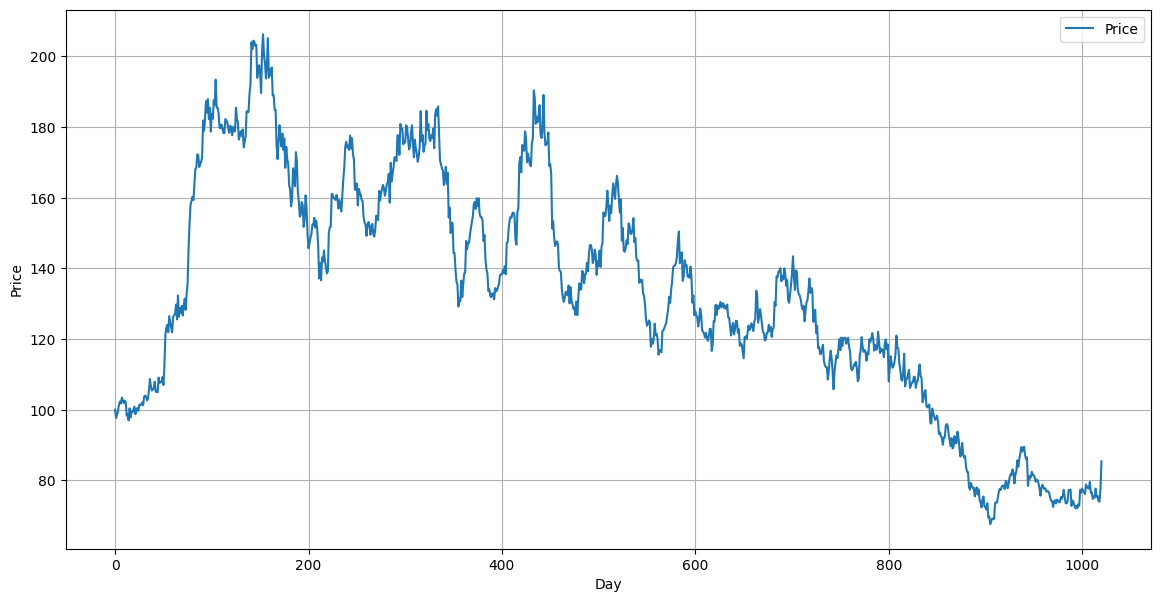

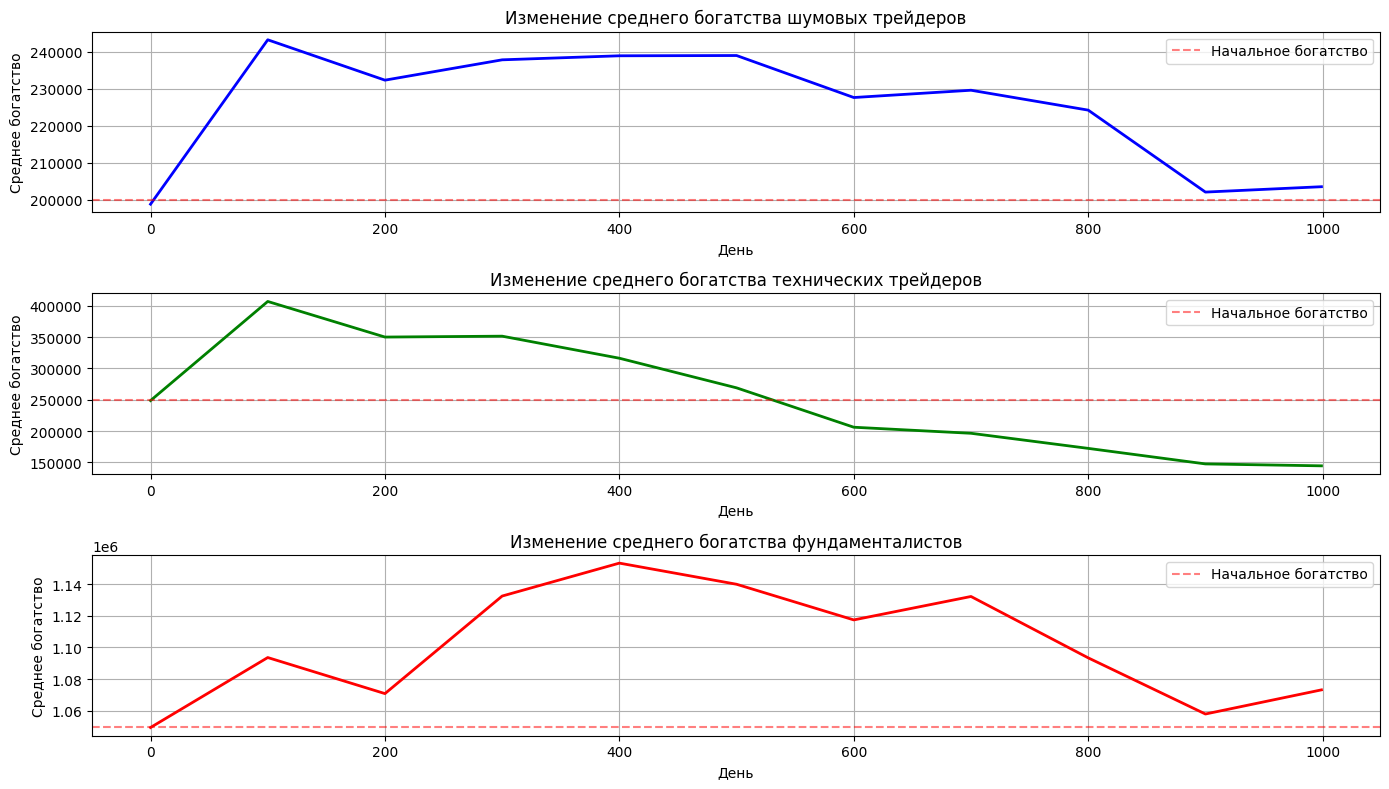

In [ ]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

Теперь взглянем на гистограммы распределений совоккупного богатства у различных типов агентов:

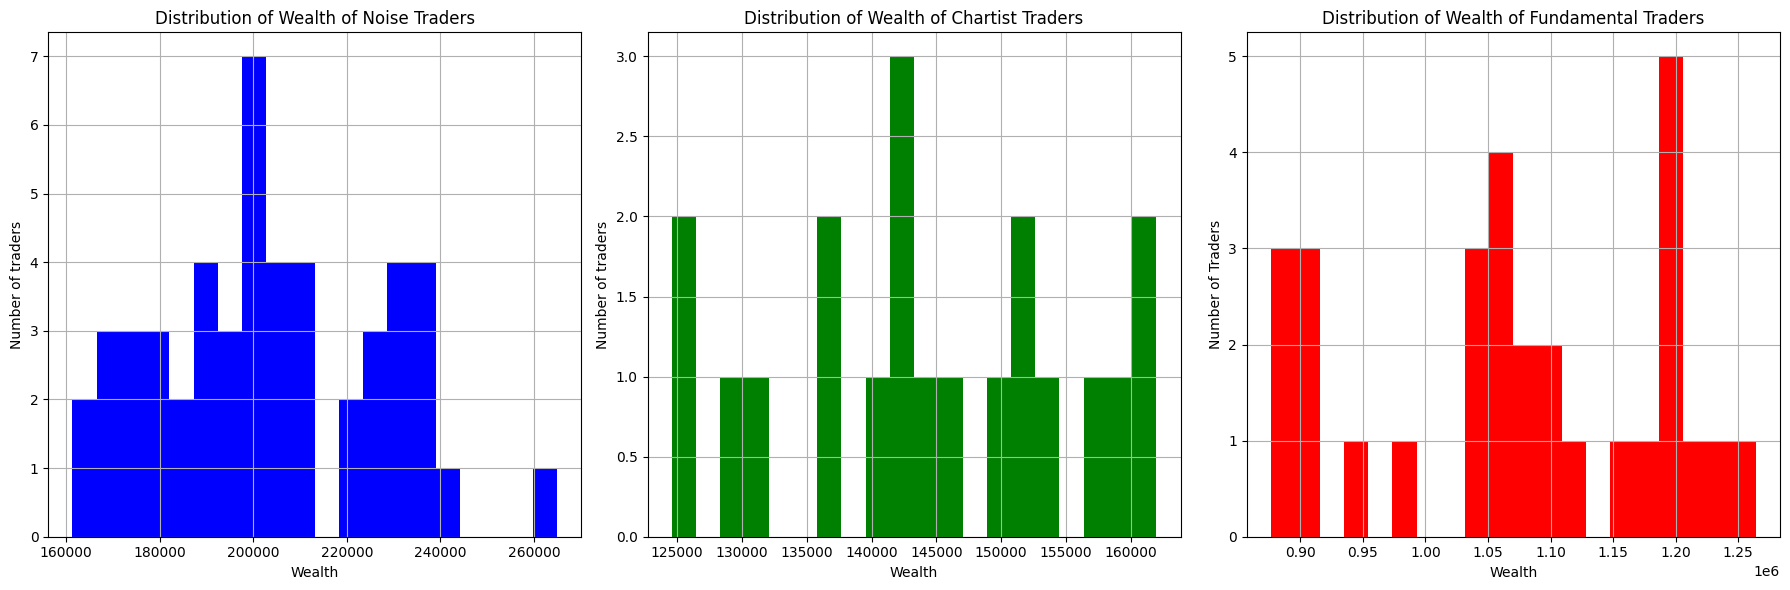

In [ ]:
noise_wealth = [t.wealth_history[-1] for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

Модифицируем агентную модель и увеличим количество шумовых трейдеров в 10 раз:

In [13]:
wealth_history = {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=500, chartists=20, fundamentalists=30):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []
    for day in range(days):
        asset.update_dividend()
        for trader in traders:
            if trader.cash <= 0 and trader.assets <= 0:
                trader.active = False
                continue
            order_type, price, qty = trader.make_decision(asset)
            if order_type and price and qty:
                order_book.add_order(order_type, price, qty, id(trader))
        executed = order_book.match_orders(traders, asset)
        for trader in traders:
            trader.update_wealth(asset.current_price)
        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    noise_wealth.append(current_wealth)
                elif trader.type == 'chartist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    chartist_wealth.append(current_wealth)
                elif trader.type == 'fundamentalist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            print(f"Active Traders - Noise: {noise_stats['active']}/{noise_traders}, "
                  f"Chartists: {chart_stats['active']}/{chartists}, "
                  f"Fundamentalists: {fund_stats['active']}/{fundamentalists}")
            if noise_stats['active'] > 0:
                print("Noise Traders:")
                print(f"  Avg Cash: {np.mean(noise_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(noise_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print("Chartist Traders:")
                print(f"  Avg Cash: {np.mean(chart_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(chart_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print("Fundamentalist Traders:")
                print(f"  Avg Cash: {np.mean(fund_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(fund_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        is_profitable = final_wealth > initial_wealth
        if is_profitable:
            total_profitable += 1
            if trader.type == 'noise':
                profitable_noise += 1
            elif trader.type == 'chartist':
                profitable_chartists += 1
            elif trader.type == 'fundamentalist':
                profitable_fundamentalists += 1
    total_traders = len(traders)
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры, вышедшие в плюс: {profitable_noise}/{noise_traders} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры, вышедшие в плюс: {profitable_chartists}/{chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты, вышедшие в плюс: {profitable_fundamentalists}/{fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент трейдеров в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
        if trader.type == 'noise':
            noise_wealth_change.append(wealth_change)
        elif trader.type == 'chartist':
            chartist_wealth_change.append(wealth_change)
        elif trader.type == 'fundamentalist':
            fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Среднее изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Среднее изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Среднее изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")
    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")
    return asset, traders

Запустим модель:


Day 0: Price = 112.01
Active Traders - Noise: 500/500, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 100588.93
  Avg Assets: 994.73
  Avg Wealth: 212006.82
Chartist Traders:
  Avg Cash: 135276.65
  Avg Assets: 1131.75
  Avg Wealth: 262041.90
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1056004.09

Day 100: Price = 80.78
Active Traders - Noise: 500/500, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 96627.70
  Avg Assets: 1036.32
  Avg Wealth: 180342.88
Chartist Traders:
  Avg Cash: 234307.49
  Avg Assets: 91.90
  Avg Wealth: 241731.25
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1040390.45

Day 200: Price = 59.11
Active Traders - Noise: 500/500, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 96351.85
  Avg Assets: 1040.00
  Avg Wealth: 157830.36
Chartist Traders:
  Avg Cash: 241203.87
  Avg Assets: 0.00
  Avg Wealth: 241203.87
Fundamentalist Traders

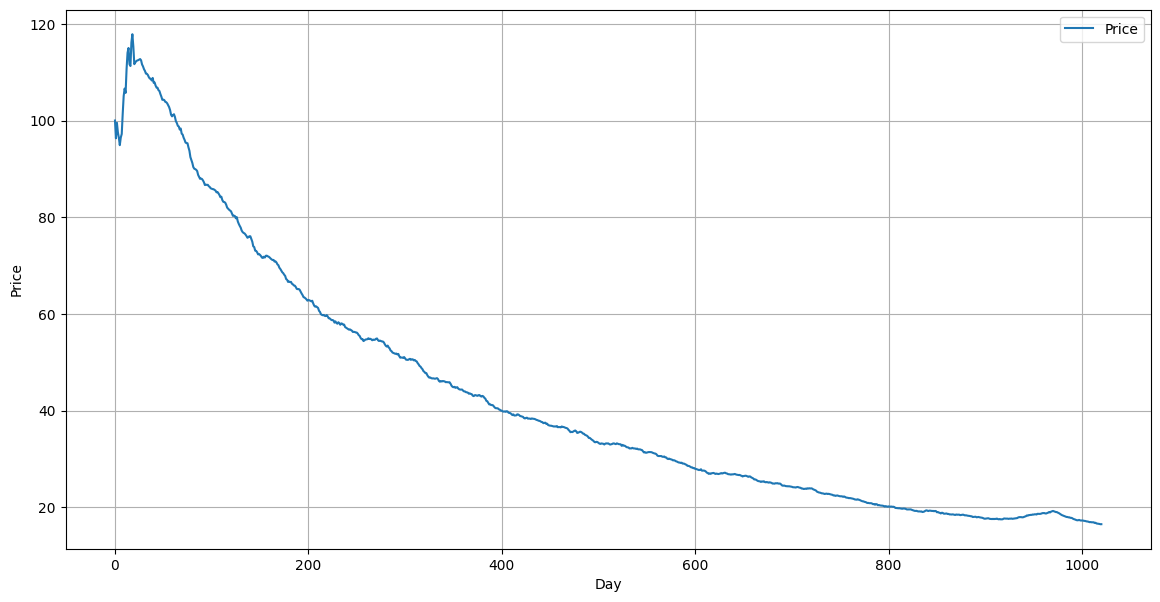

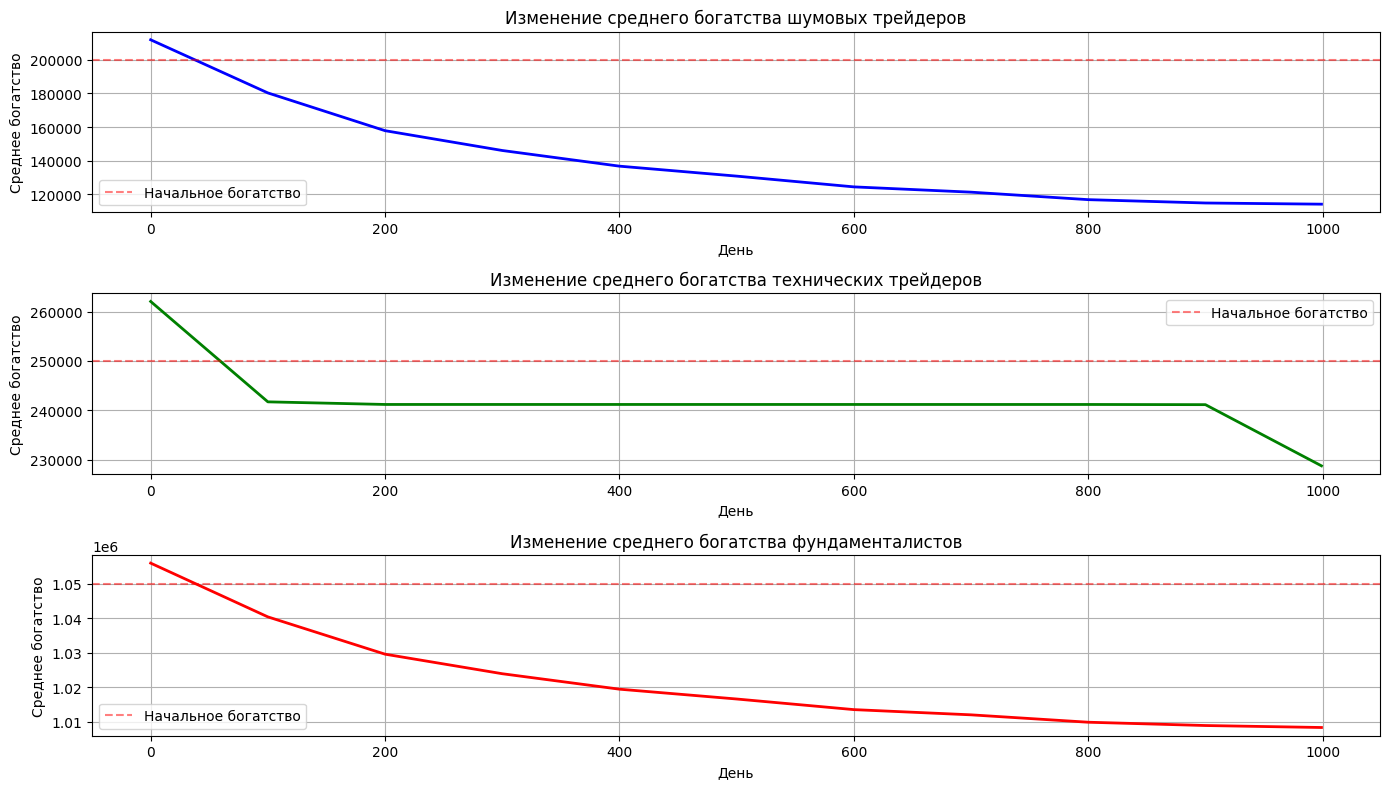

In [15]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

Взглянем на гистограммы распределений совокупного богатства у различных типов агентов:

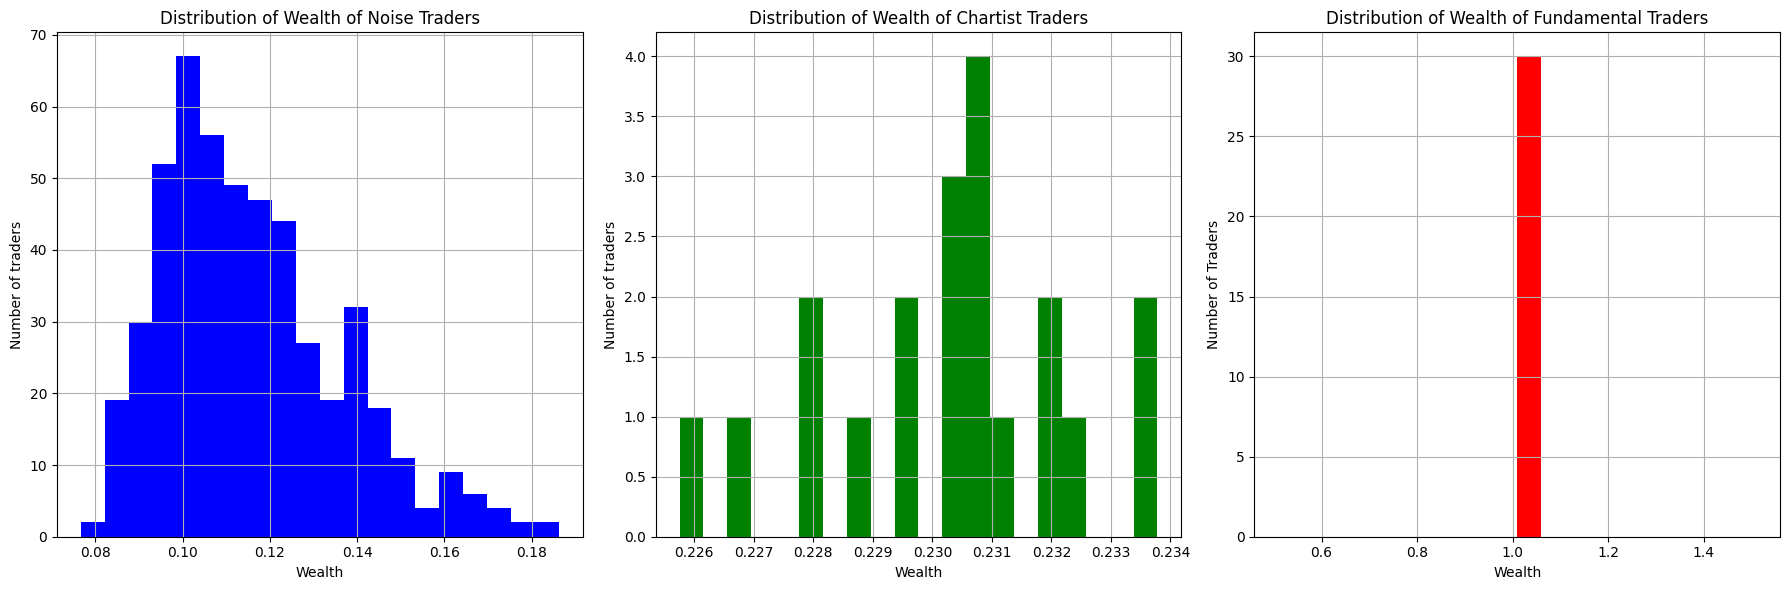

In [ ]:
noise_wealth = [t.wealth_history[-1] / 1e6 for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] / 1e6 for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] / 1e6 for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

Теперь запустим обучение, в котором будет раздуто количество технических трейдеров:

In [ ]:
wealth_history = {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=25, chartists=130, fundamentalists=15):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []
    for day in range(days):
        asset.update_dividend()
        for trader in traders:
            if trader.cash <= 0 and trader.assets <= 0:
                trader.active = False
                continue
            order_type, price, qty = trader.make_decision(asset)
            if order_type and price and qty:
                order_book.add_order(order_type, price, qty, id(trader))
        executed = order_book.match_orders(traders, asset)
        for trader in traders:
            trader.update_wealth(asset.current_price)
        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    noise_wealth.append(current_wealth)
                elif trader.type == 'chartist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    chartist_wealth.append(current_wealth)
                elif trader.type == 'fundamentalist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            print(f"Active Traders - Noise: {noise_stats['active']}/{noise_traders}, "
                  f"Chartists: {chart_stats['active']}/{chartists}, "
                  f"Fundamentalists: {fund_stats['active']}/{fundamentalists}")
            if noise_stats['active'] > 0:
                print("Noise Traders:")
                print(f"  Avg Cash: {np.mean(noise_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(noise_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print("Chartist Traders:")
                print(f"  Avg Cash: {np.mean(chart_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(chart_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print("Fundamentalist Traders:")
                print(f"  Avg Cash: {np.mean(fund_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(fund_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        is_profitable = final_wealth > initial_wealth
        if is_profitable:
            total_profitable += 1
            if trader.type == 'noise':
                profitable_noise += 1
            elif trader.type == 'chartist':
                profitable_chartists += 1
            elif trader.type == 'fundamentalist':
                profitable_fundamentalists += 1
    total_traders = len(traders)
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры, вышедшие в плюс: {profitable_noise}/{noise_traders} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры, вышедшие в плюс: {profitable_chartists}/{chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты, вышедшие в плюс: {profitable_fundamentalists}/{fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент трейдеров в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
        if trader.type == 'noise':
            noise_wealth_change.append(wealth_change)
        elif trader.type == 'chartist':
            chartist_wealth_change.append(wealth_change)
        elif trader.type == 'fundamentalist':
            fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Среднее изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Среднее изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Среднее изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")
    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")
    return asset, traders

Запустим модель:


Day 0: Price = 111.21
Active Traders - Noise: 25/25, Chartists: 130/130, Fundamentalists: 15/15
Noise Traders:
  Avg Cash: 103257.25
  Avg Assets: 970.44
  Avg Wealth: 211178.26
Chartist Traders:
  Avg Cash: 149373.61
  Avg Assets: 1005.68
  Avg Wealth: 261214.11
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1055604.16

Day 100: Price = 538.78
Active Traders - Noise: 25/25, Chartists: 130/130, Fundamentalists: 15/15
Noise Traders:
  Avg Cash: 261595.99
  Avg Assets: 45.24
  Avg Wealth: 285970.35
Chartist Traders:
  Avg Cash: 107692.09
  Avg Assets: 1211.65
  Avg Wealth: 760501.40
Fundamentalist Traders:
  Avg Cash: 1097341.88
  Avg Assets: 257.00
  Avg Wealth: 1235808.04

Day 200: Price = 5398.59
Active Traders - Noise: 25/25, Chartists: 130/130, Fundamentalists: 15/15
Noise Traders:
  Avg Cash: 320694.66
  Avg Assets: 0.20
  Avg Wealth: 321774.38
Chartist Traders:
  Avg Cash: 57857.18
  Avg Assets: 1245.68
  Avg Wealth: 6782799.59
Fundamentalist Tr

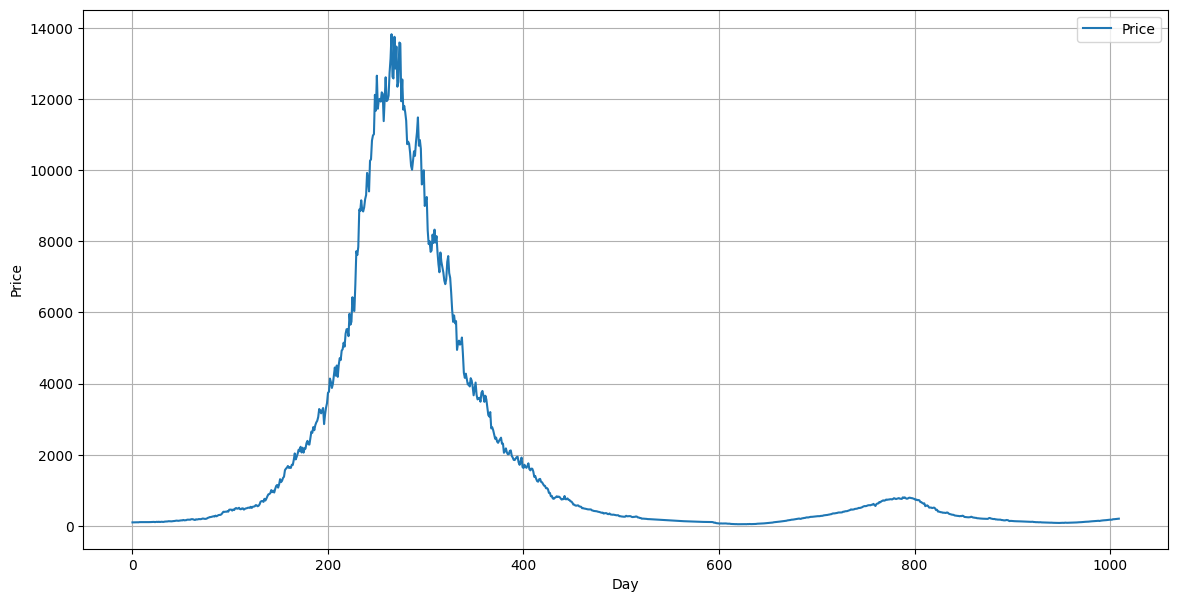

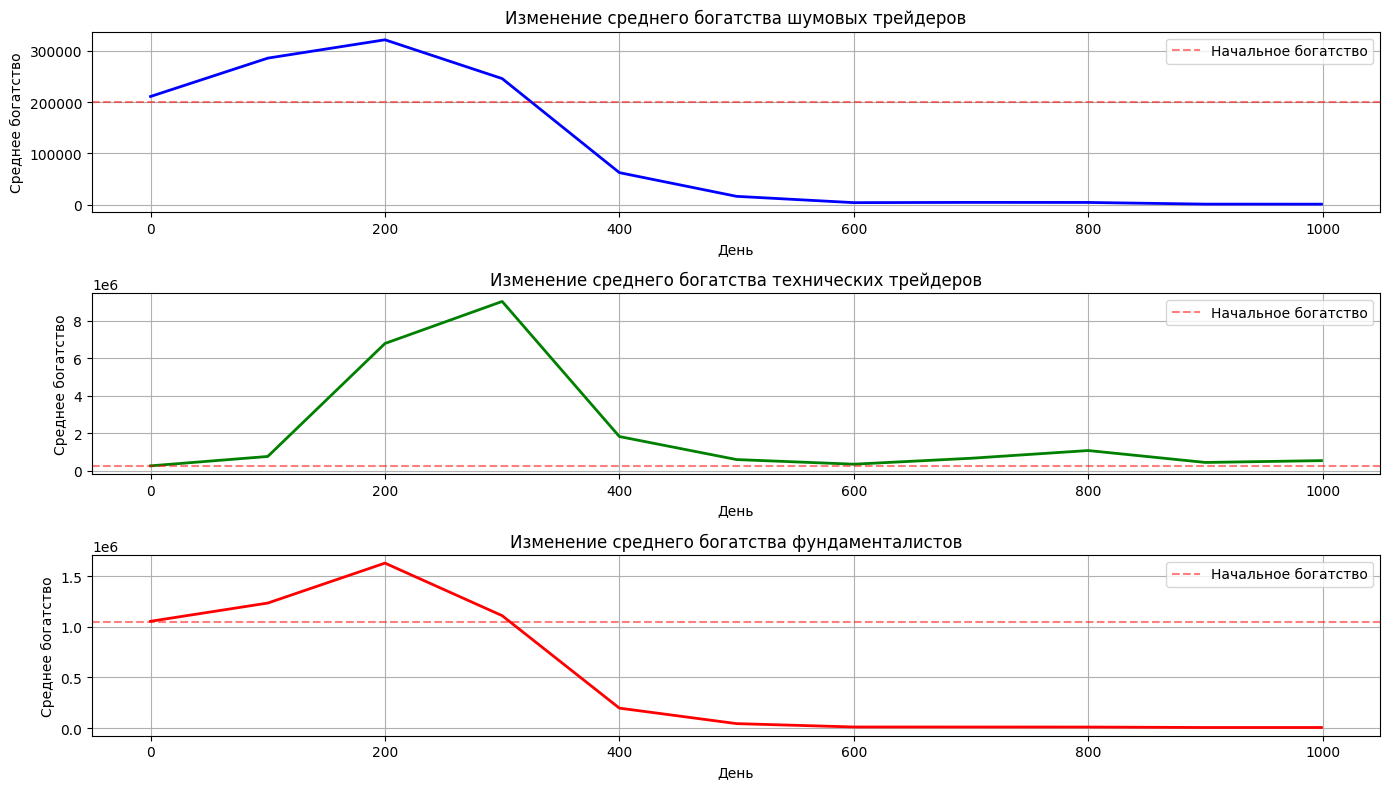

In [ ]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

Вновь взглянем на гистограммы распределений совокупного богатства у различных типов трейдеров:

In [ ]:
noise_wealth = [t.wealth_history[-1] for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'traders' is not defined

Теперь же увеличим количество фундаменталистов в 10 раз:

In [ ]:
wealth_history = {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=50, chartists=20, fundamentalists=300):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []
    for day in range(days):
        asset.update_dividend()
        for trader in traders:
            if trader.cash <= 0 and trader.assets <= 0:
                trader.active = False
                continue
            order_type, price, qty = trader.make_decision(asset)
            if order_type and price and qty:
                order_book.add_order(order_type, price, qty, id(trader))
        executed = order_book.match_orders(traders, asset)
        for trader in traders:
            trader.update_wealth(asset.current_price)
        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    noise_wealth.append(current_wealth)
                elif trader.type == 'chartist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    chartist_wealth.append(current_wealth)
                elif trader.type == 'fundamentalist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            print(f"Active Traders - Noise: {noise_stats['active']}/{noise_traders}, "
                  f"Chartists: {chart_stats['active']}/{chartists}, "
                  f"Fundamentalists: {fund_stats['active']}/{fundamentalists}")
            if noise_stats['active'] > 0:
                print("Noise Traders:")
                print(f"  Avg Cash: {np.mean(noise_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(noise_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print("Chartist Traders:")
                print(f"  Avg Cash: {np.mean(chart_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(chart_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print("Fundamentalist Traders:")
                print(f"  Avg Cash: {np.mean(fund_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(fund_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        is_profitable = final_wealth > initial_wealth
        if is_profitable:
            total_profitable += 1
            if trader.type == 'noise':
                profitable_noise += 1
            elif trader.type == 'chartist':
                profitable_chartists += 1
            elif trader.type == 'fundamentalist':
                profitable_fundamentalists += 1
    total_traders = len(traders)
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры, вышедшие в плюс: {profitable_noise}/{noise_traders} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры, вышедшие в плюс: {profitable_chartists}/{chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты, вышедшие в плюс: {profitable_fundamentalists}/{fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент трейдеров в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
        if trader.type == 'noise':
            noise_wealth_change.append(wealth_change)
        elif trader.type == 'chartist':
            chartist_wealth_change.append(wealth_change)
        elif trader.type == 'fundamentalist':
            fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Среднее изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Среднее изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Среднее изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")
    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")
    return asset, traders

Запустим симуляцию:


Day 0: Price = 100.95
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 300/300
Noise Traders:
  Avg Cash: 101554.78
  Avg Assets: 984.74
  Avg Wealth: 200968.02
Chartist Traders:
  Avg Cash: 146113.06
  Avg Assets: 1038.15
  Avg Wealth: 250918.25
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1050476.90

Day 100: Price = 138.39
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 300/300
Noise Traders:
  Avg Cash: 173715.27
  Avg Assets: 159.76
  Avg Wealth: 195823.71
Chartist Traders:
  Avg Cash: 124741.60
  Avg Assets: 1163.05
  Avg Wealth: 285690.62
Fundamentalist Traders:
  Avg Cash: 989398.01
  Avg Assets: 629.17
  Avg Wealth: 1076465.89

Day 200: Price = 210.40
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 300/300
Noise Traders:
  Avg Cash: 196648.05
  Avg Assets: 18.76
  Avg Wealth: 200595.20
Chartist Traders:
  Avg Cash: 174042.73
  Avg Assets: 825.40
  Avg Wealth: 347709.08
Fundamentalist Tra

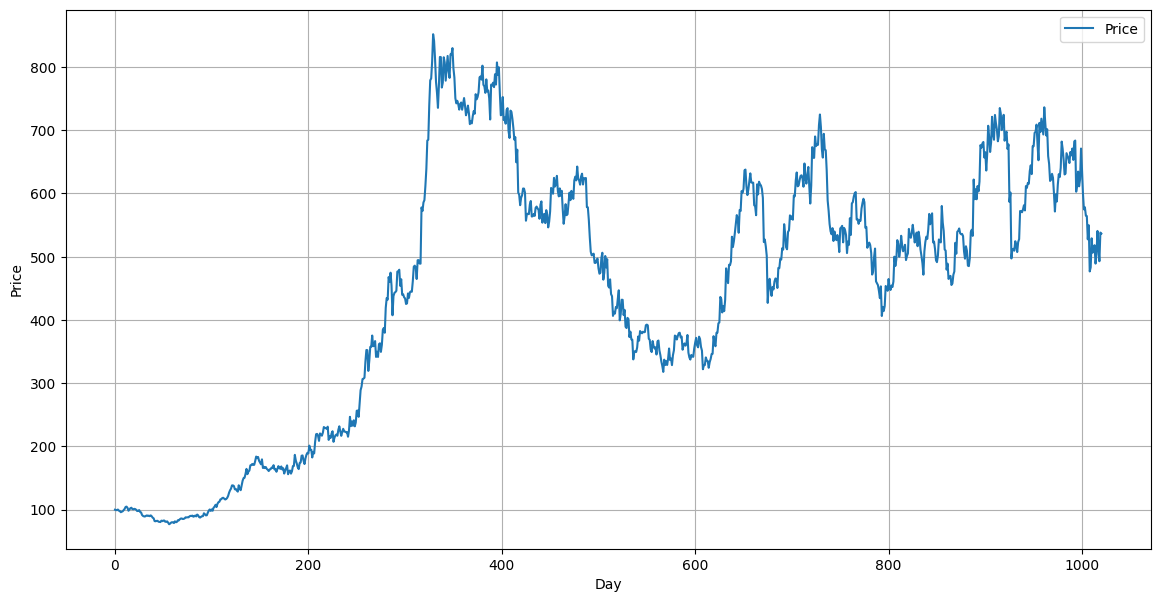

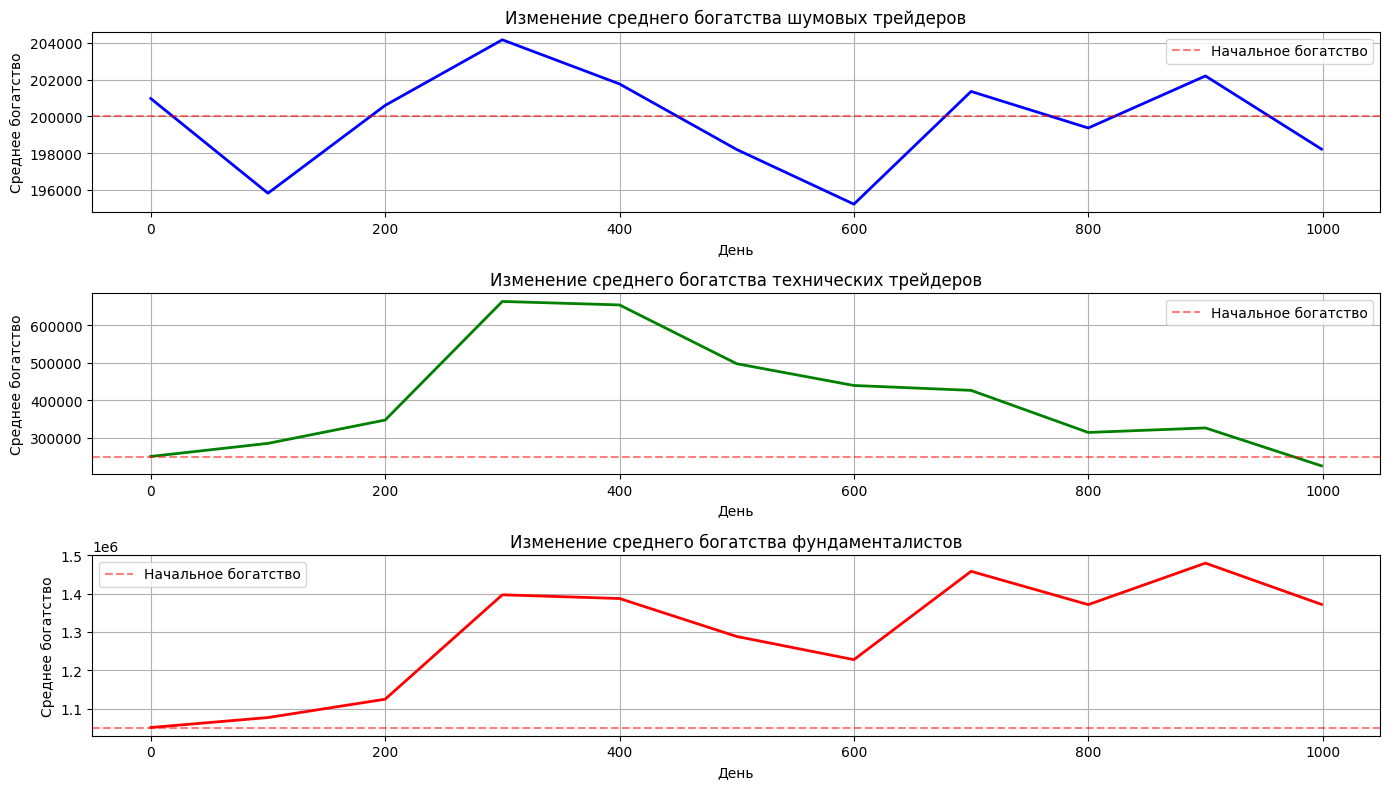

In [ ]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

Взглянем на гистограммы распределений совокупного богатства:

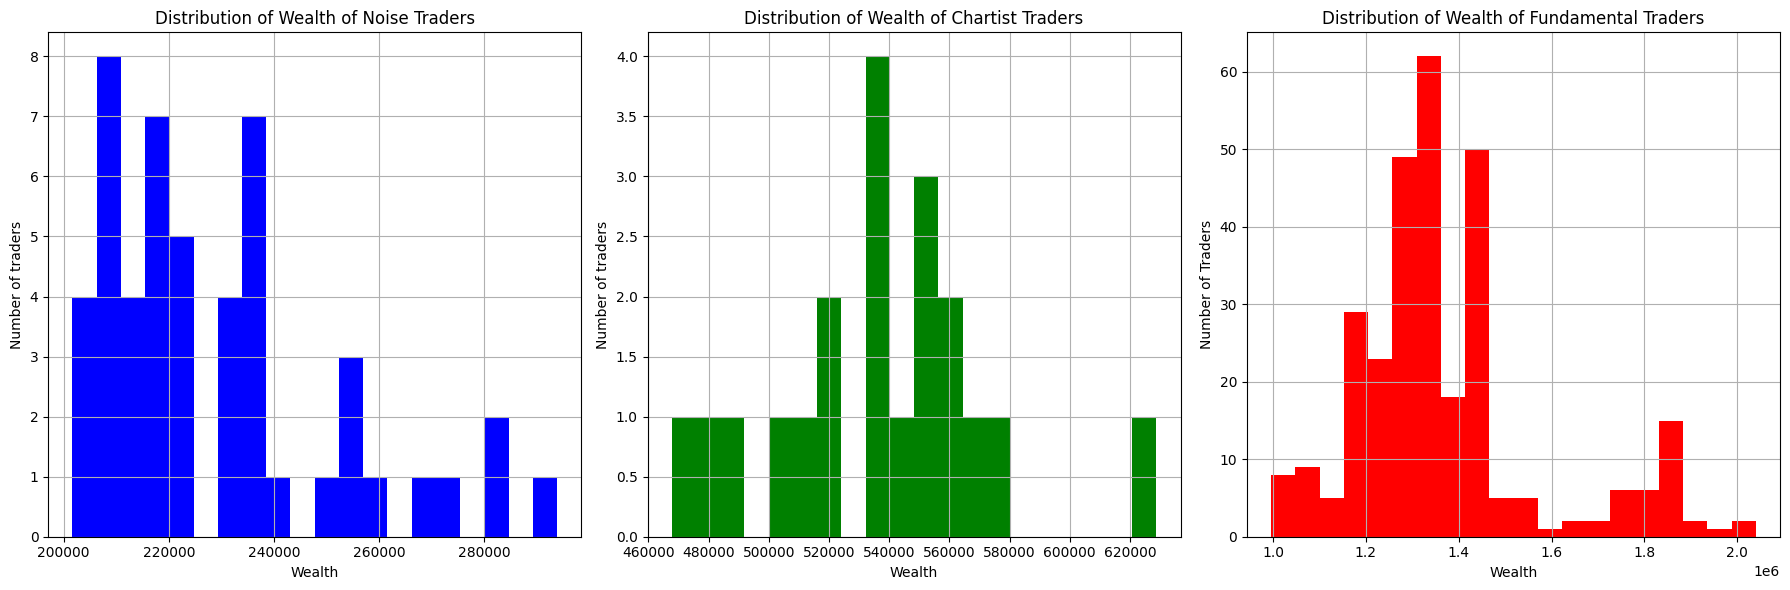

In [ ]:
noise_wealth = [t.wealth_history[-1] for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

На этот раз модифицируем базовую агентную модель посредством добавления остановки торгов в случае, если цена бумаги в какой-либо день отличается на 20% от цены предыдущего дня. Для этого необходимо модифицировать класс функций актива, книги заявок и запуска симуляции модели, остальные классы можно оставить без изменений. Сделаем это ниже:

In [ ]:
class Asset:
    def __init__(self, initial_price=100):
        self.price_history = [initial_price]
        self.dividend_history = [0.016]
        self.current_price = initial_price
        self.trading_halted = False
        self.halt_threshold = 0.20  # изменение в 20% от пред. дня
        self.halt_duration = 5      # остановка на 5 дней
        self.halt_remaining = 0
        self.last_check_price = initial_price

    def update_price(self, new_price):
        if not self.trading_halted:
            price_change = abs(new_price / self.last_check_price - 1)
            if price_change > self.halt_threshold:
                self.trading_halted = True
                self.halt_remaining = self.halt_duration
                print(f"\nCircuit Breaker: Торги остановлены на {self.halt_duration} дней (изменение {price_change:.2%} > {self.halt_threshold:.2%})")
                return False

        self.current_price = new_price
        self.price_history.append(new_price)
        return True

    def update_dividend(self, rd=0.0008, sigma_d=0.0008):
        if np.random.rand() < 0.01:
            shock = np.random.randn() * 0.005
        else:
            shock = 0
        new_div = self.dividend_history[-1] * (1 + rd + sigma_d * np.random.randn() + shock)
        self.dividend_history.append(max(new_div, 0))
        return self.dividend_history[-1]

    def check_halt_status(self):
        if self.trading_halted:
            self.halt_remaining -= 1
            if self.halt_remaining <= 0:
                self.trading_halted = False
                self.last_check_price = self.current_price
                print("\nCircuit Breaker: Торги возобновлены")
        else:
            if len(self.price_history) > 0:
                self.last_check_price = self.price_history[-1]

        return self.trading_halted

In [ ]:
wealth_history= {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=50, chartists=20, fundamentalists=30):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []

    for day in range(days):
        asset.update_dividend()
        trading_halted = asset.check_halt_status()

        if not trading_halted:
            for trader in traders:
                if trader.cash <= 0 and trader.assets <= 0:
                    trader.active = False
                    continue
                order_type, price, qty = trader.make_decision(asset)
                if order_type and price and qty:
                    order_book.add_order(order_type, price, qty, id(trader))
            executed = order_book.match_orders(traders, asset)

        for trader in traders:
            trader.update_wealth(asset.current_price)

        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    noise_wealth.append(current_wealth)
                elif trader.type == 'chartist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    chartist_wealth.append(current_wealth)
                elif trader.type == 'fundamentalist' and trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            if trading_halted:
                print(f"Торги остановлены! Осталось дней: {asset.halt_remaining}")
            print(f"Active Traders - Noise: {noise_stats['active']}/{noise_traders}, "
                  f"Chartists: {chart_stats['active']}/{chartists}, "
                  f"Fundamentalists: {fund_stats['active']}/{fundamentalists}")
            if noise_stats['active'] > 0:
                print("Noise Traders:")
                print(f"  Avg Cash: {np.mean(noise_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(noise_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print("Chartist Traders:")
                print(f"  Avg Cash: {np.mean(chart_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(chart_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print("Fundamentalist Traders:")
                print(f"  Avg Cash: {np.mean(fund_stats['cash']):.2f}")
                print(f"  Avg Assets: {np.mean(fund_stats['assets']):.2f}")
                print(f"  Avg Wealth: {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ (Circuit Breaker)")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        is_profitable = final_wealth > initial_wealth
        if is_profitable:
            total_profitable += 1
            if trader.type == 'noise':
                profitable_noise += 1
            elif trader.type == 'chartist':
                profitable_chartists += 1
            elif trader.type == 'fundamentalist':
                profitable_fundamentalists += 1
    total_traders = len(traders)
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры, вышедшие в плюс: {profitable_noise}/{noise_traders} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры, вышедшие в плюс: {profitable_chartists}/{chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты, вышедшие в плюс: {profitable_fundamentalists}/{fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент трейдеров в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        initial_wealth = initial_wealths[id(trader)]
        final_wealth = trader.wealth_history[-1]
        wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
        if trader.type == 'noise':
            noise_wealth_change.append(wealth_change)
        elif trader.type == 'chartist':
            chartist_wealth_change.append(wealth_change)
        elif trader.type == 'fundamentalist':
            fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Среднее изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Среднее изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Среднее изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")

    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")

    return asset, traders


Day 0: Price = 99.64
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 97143.77
  Avg Assets: 1028.80
  Avg Wealth: 199651.14
Chartist Traders:
  Avg Cash: 157140.57
  Avg Assets: 928.00
  Avg Wealth: 249604.45
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1049818.90

Day 100: Price = 53.94
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 97275.63
  Avg Assets: 904.56
  Avg Wealth: 146066.91
Chartist Traders:
  Avg Cash: 156810.91
  Avg Assets: 1238.60
  Avg Wealth: 223620.05
Fundamentalist Traders:
  Avg Cash: 1000000.00
  Avg Assets: 500.00
  Avg Wealth: 1026969.62

Day 200: Price = 223.35
Active Traders - Noise: 50/50, Chartists: 20/20, Fundamentalists: 30/30
Noise Traders:
  Avg Cash: 153272.07
  Avg Assets: 0.66
  Avg Wealth: 153419.48
Chartist Traders:
  Avg Cash: 70456.51
  Avg Assets: 2546.35
  Avg Wealth: 639185.62
Fundamentalist Traders:
  Av

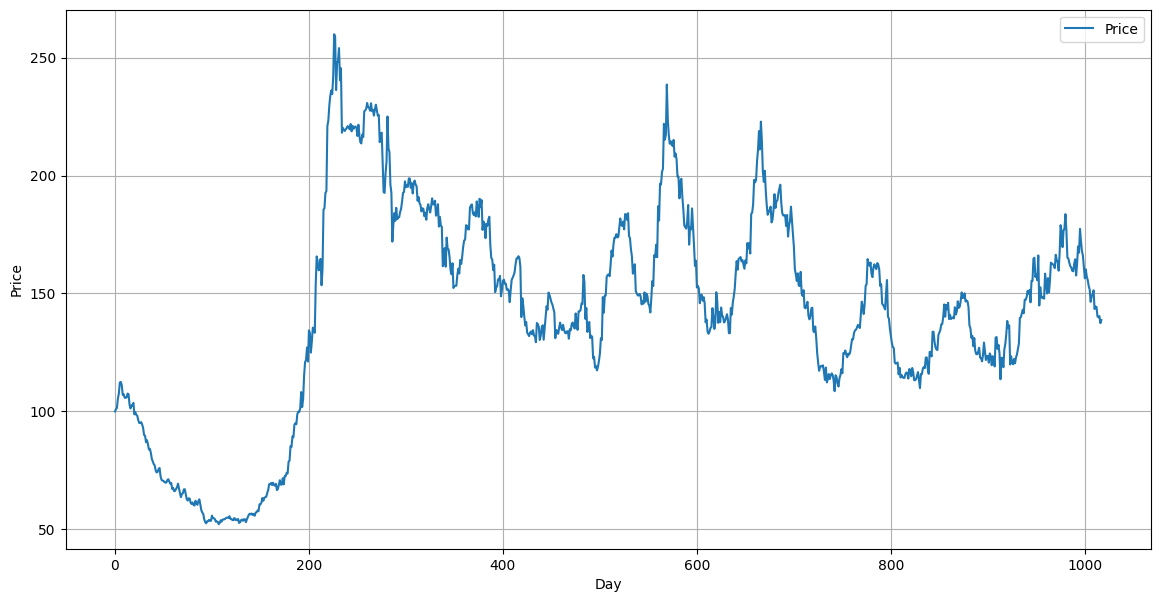

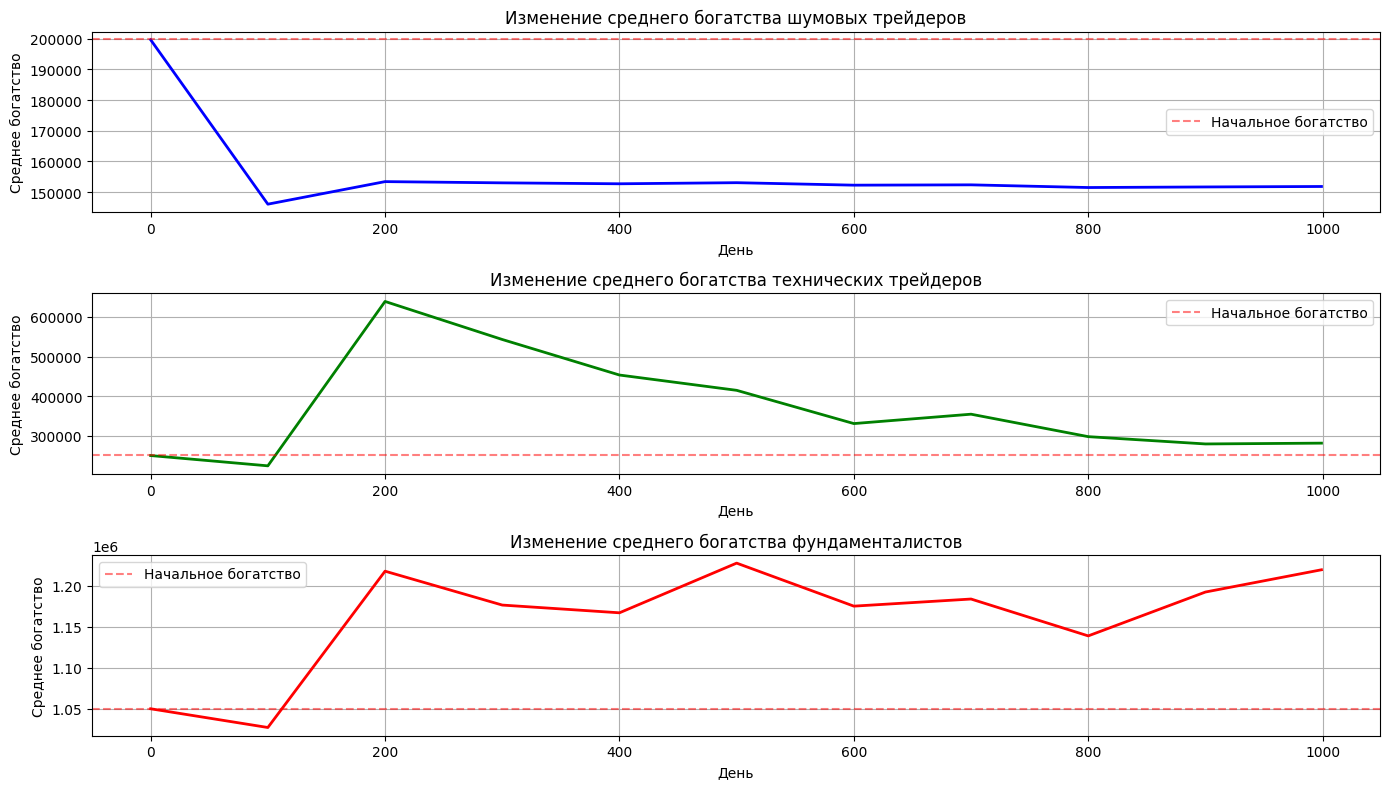

In [ ]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

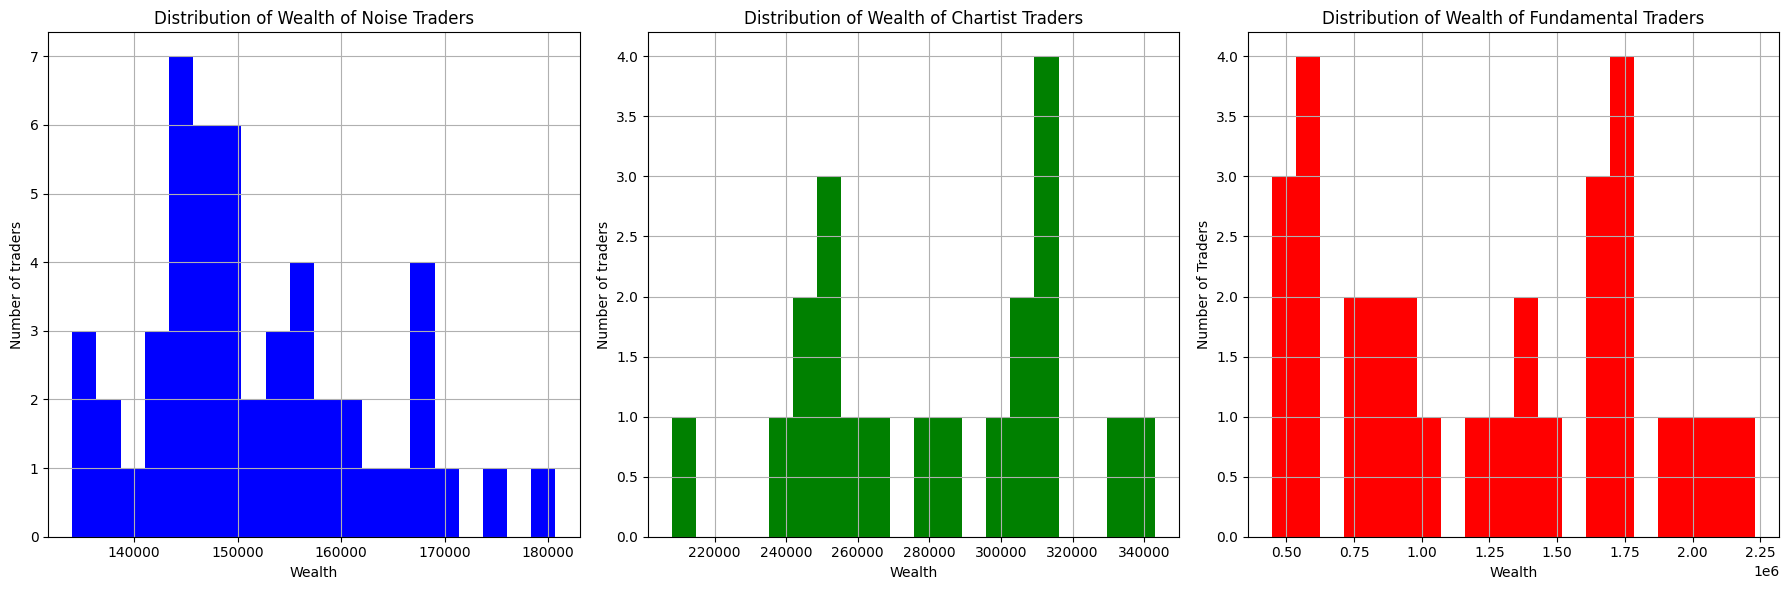

In [ ]:
noise_wealth = [t.wealth_history[-1] for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

Теперь же расширим модель и применим для нее эволюцию трейдеров - каждые 100 дней(каждый период) 2 случайных шумовых трейдера становятся чартистами, а также 1 чартист становится фундаменталистом:

In [ ]:
wealth_history = {
    'days': [],
    'noise_avg': [],
    'chartist_avg': [],
    'fundamentalist_avg': []
}

def run_simulation(days=1000, noise_traders=50, chartists=20, fundamentalists=30):
    asset = Asset()
    order_book = OrderBook()
    traders = []
    for _ in range(noise_traders):
        traders.append(NoiseTrader(cash=100000, assets=1000))
    for _ in range(chartists):
        traders.append(ChartistTrader(cash=150000, assets=1000, window=20, alpha=0.1))
    for _ in range(fundamentalists):
        traders.append(FundamentalistTrader(cash=1000000, assets=500, gamma=2, rf=0.0003))
    for _ in range(20):
        new_price = asset.current_price * np.exp(0.0003 - 0.02**2/2 + 0.02*np.random.randn())
        asset.update_price(new_price)
        asset.update_dividend()
    initial_wealths = {}
    for trader in traders:
        initial_wealths[id(trader)] = trader.wealth_history[0]
    wealth_history['days'] = []
    wealth_history['noise_avg'] = []
    wealth_history['chartist_avg'] = []
    wealth_history['fundamentalist_avg'] = []

    for day in range(days):
        asset.update_dividend()

        # Эволюция трейдеров каждые 100 дней
        if day % 100 == 0 and day > 0:
            print(f"\nЭволюция трейдеров на день {day}")
            noise_traders_list = [t for t in traders if t.type == 'noise' and t.active]
            if len(noise_traders_list) >= 2:
                traders_to_evolve = np.random.choice(noise_traders_list, 2, replace=False)
                for trader in traders_to_evolve:
                    new_chartist = ChartistTrader(cash=trader.cash, assets=trader.assets, window=20, alpha=0.1)
                    new_chartist.wealth_history = trader.wealth_history.copy()
                    traders.append(new_chartist)
                    trader.active = False
                    print(f"Шумовой трейдер эволюционировал в чартиста (активы: {trader.assets}, cash: {trader.cash:.2f})")
            chartist_traders_list = [t for t in traders if t.type == 'chartist' and t.active]
            if len(chartist_traders_list) >= 1:
                trader_to_evolve = np.random.choice(chartist_traders_list, 1)[0]
                new_fundamentalist = FundamentalistTrader(cash=trader_to_evolve.cash, assets=trader_to_evolve.assets, gamma=2, rf=0.0003)
                new_fundamentalist.wealth_history = trader_to_evolve.wealth_history.copy()
                traders.append(new_fundamentalist)
                trader_to_evolve.active = False
                print(f"Чартист эволюционировал в фундаменталиста (активы: {trader_to_evolve.assets}, cash: {trader_to_evolve.cash:.2f})")

        for trader in traders:
            if trader.cash <= 0 and trader.assets <= 0:
                trader.active = False
                continue
            order_type, price, qty = trader.make_decision(asset)
            if order_type and price and qty:
                order_book.add_order(order_type, price, qty, id(trader))
        executed = order_book.match_orders(traders, asset)
        for trader in traders:
            trader.update_wealth(asset.current_price)

        if day % 100 == 0 or day == days-1:
            noise_wealth = []
            chartist_wealth = []
            fundamentalist_wealth = []
            for trader in traders:
                if trader.active:
                    current_wealth = trader.cash + trader.assets * asset.current_price
                    if trader.type == 'noise':
                        noise_wealth.append(current_wealth)
                    elif trader.type == 'chartist':
                        chartist_wealth.append(current_wealth)
                    elif trader.type == 'fundamentalist':
                        fundamentalist_wealth.append(current_wealth)
            wealth_history['days'].append(day)
            if noise_wealth:
                wealth_history['noise_avg'].append(np.mean(noise_wealth))
            else:
                wealth_history['noise_avg'].append(0)
            if chartist_wealth:
                wealth_history['chartist_avg'].append(np.mean(chartist_wealth))
            else:
                wealth_history['chartist_avg'].append(0)
            if fundamentalist_wealth:
                wealth_history['fundamentalist_avg'].append(np.mean(fundamentalist_wealth))
            else:
                wealth_history['fundamentalist_avg'].append(0)
            noise_stats = {'cash': [], 'assets': [], 'active': 0}
            chart_stats = {'cash': [], 'assets': [], 'active': 0}
            fund_stats = {'cash': [], 'assets': [], 'active': 0}
            for trader in traders:
                if trader.type == 'noise' and trader.active:
                    noise_stats['cash'].append(trader.cash)
                    noise_stats['assets'].append(trader.assets)
                    noise_stats['active'] += 1
                elif trader.type == 'chartist' and trader.active:
                    chart_stats['cash'].append(trader.cash)
                    chart_stats['assets'].append(trader.assets)
                    chart_stats['active'] += 1
                elif trader.type == 'fundamentalist' and trader.active:
                    fund_stats['cash'].append(trader.cash)
                    fund_stats['assets'].append(trader.assets)
                    fund_stats['active'] += 1
            total_active = noise_stats['active'] + chart_stats['active'] + fund_stats['active']
            print(f"\nDay {day}: Price = {asset.current_price:.2f}")
            print(f"Всего активных трейдеров: {total_active}")
            print(f"Active Traders - Noise: {noise_stats['active']}, Chartists: {chart_stats['active']}, Fundamentalists: {fund_stats['active']}")
            if noise_stats['active'] > 0:
                print(f"Noise Traders: Avg Cash = {np.mean(noise_stats['cash']):.2f}, Avg Assets = {np.mean(noise_stats['assets']):.2f}, Avg Wealth = {wealth_history['noise_avg'][-1]:.2f}")
            if chart_stats['active'] > 0:
                print(f"Chartists: Avg Cash = {np.mean(chart_stats['cash']):.2f}, Avg Assets = {np.mean(chart_stats['assets']):.2f}, Avg Wealth = {wealth_history['chartist_avg'][-1]:.2f}")
            if fund_stats['active'] > 0:
                print(f"Fundamentalists: Avg Cash = {np.mean(fund_stats['cash']):.2f}, Avg Assets = {np.mean(fund_stats['assets']):.2f}, Avg Wealth = {wealth_history['fundamentalist_avg'][-1]:.2f}")

    print("АНАЛИЗ РЕЗУЛЬТАТОВ СИМУЛЯЦИИ (ЭВОЛЮЦИЯ)")
    profitable_noise = 0
    profitable_chartists = 0
    profitable_fundamentalists = 0
    total_profitable = 0
    for trader in traders:
        if id(trader) in initial_wealths:
            initial_wealth = initial_wealths[id(trader)]
            final_wealth = trader.wealth_history[-1]
            is_profitable = final_wealth > initial_wealth
            if is_profitable:
                total_profitable += 1
                if trader.type == 'noise':
                    profitable_noise += 1
                elif trader.type == 'chartist':
                    profitable_chartists += 1
                elif trader.type == 'fundamentalist':
                    profitable_fundamentalists += 1
    total_traders = len([t for t in traders if id(t) in initial_wealths])
    profitable_percentage = (total_profitable / total_traders) * 100
    print(f"Шумовые трейдеры в плюсе: {profitable_noise} ({profitable_noise/noise_traders*100:.1f}%)")
    print(f"Технические трейдеры в плюсе: {profitable_chartists} ({profitable_chartists/chartists*100:.1f}%)")
    print(f"Фундаменталисты в плюсе: {profitable_fundamentalists} ({profitable_fundamentalists/fundamentalists*100:.1f}%)")
    print(f"Общий процент в плюсе: {total_profitable}/{total_traders} ({profitable_percentage:.1f}%)")
    noise_wealth_change = []
    chartist_wealth_change = []
    fundamentalist_wealth_change = []
    for trader in traders:
        if id(trader) in initial_wealths:
            initial_wealth = initial_wealths[id(trader)]
            final_wealth = trader.wealth_history[-1]
            wealth_change = ((final_wealth - initial_wealth) / initial_wealth) * 100
            if trader.type == 'noise':
                noise_wealth_change.append(wealth_change)
            elif trader.type == 'chartist':
                chartist_wealth_change.append(wealth_change)
            elif trader.type == 'fundamentalist':
                fundamentalist_wealth_change.append(wealth_change)
    if noise_wealth_change:
        print(f"Изменение богатства шумовых трейдеров: {np.mean(noise_wealth_change):.2f}%")
    if chartist_wealth_change:
        print(f"Изменение богатства технических трейдеров: {np.mean(chartist_wealth_change):.2f}%")
    if fundamentalist_wealth_change:
        print(f"Изменение богатства фундаменталистов: {np.mean(fundamentalist_wealth_change):.2f}%")

    print()
    price_series = np.array(asset.price_history)
    hurst_val = calculate_hurst_exponent(price_series)
    if not np.isnan(hurst_val):
        print(f"ПОКАЗАТЕЛЬ ХЕРСТА (H) = {hurst_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ХЕРСТА: не удалось рассчитать")

    lyap_val = calculate_lyapunov_exponent(price_series, emb_dim=10, lag=1)
    if not np.isnan(lyap_val):
        print(f"СТАРШИЙ ПОКАЗАТЕЛЬ ЛЯПУНОВА (λ_max) = {lyap_val:.4f}")
    else:
        print("ПОКАЗАТЕЛЬ ЛЯПУНОВА: не удалось рассчитать")

    kse_val = calculate_kolmogorov_entropy(price_series, emb_dim=3)
    if not np.isnan(kse_val):
        print(f"ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ (h_KS) = {kse_val:.4f} бит/шаг")
    else:
        print("ЭНТРОПИЯ КОЛМОГОРОВА-СИНАЯ: не удалось рассчитать")

    return asset, traders


Day 0: Price = 97.60
Всего активных трейдеров: 100
Active Traders - Noise: 50, Chartists: 20, Fundamentalists: 30
Noise Traders: Avg Cash = 99306.54, Avg Assets = 1006.96, Avg Wealth = 197587.06
Chartists: Avg Cash = 151733.65, Avg Assets = 982.60, Avg Wealth = 247636.60
Fundamentalists: Avg Cash = 1000000.00, Avg Assets = 500.00, Avg Wealth = 1048800.61

Circuit Breaker: Торги остановлены на 5 дней (изменение 20.29% > 20.00%)

Эволюция трейдеров на день 100
Шумовой трейдер эволюционировал в чартиста (активы: 0, cash: 179597.10)
Шумовой трейдер эволюционировал в чартиста (активы: 67, cash: 171081.54)
Чартист эволюционировал в фундаменталиста (активы: 2291, cash: 53194.49)

Day 100: Price = 90.42
Всего активных трейдеров: 100
Active Traders - Noise: 48, Chartists: 21, Fundamentalists: 31
Noise Traders: Avg Cash = 153527.10, Avg Assets = 273.50, Avg Wealth = 178256.26
Chartists: Avg Cash = 87604.61, Avg Assets = 1759.33, Avg Wealth = 246678.99
Fundamentalists: Avg Cash = 928742.02, Avg 

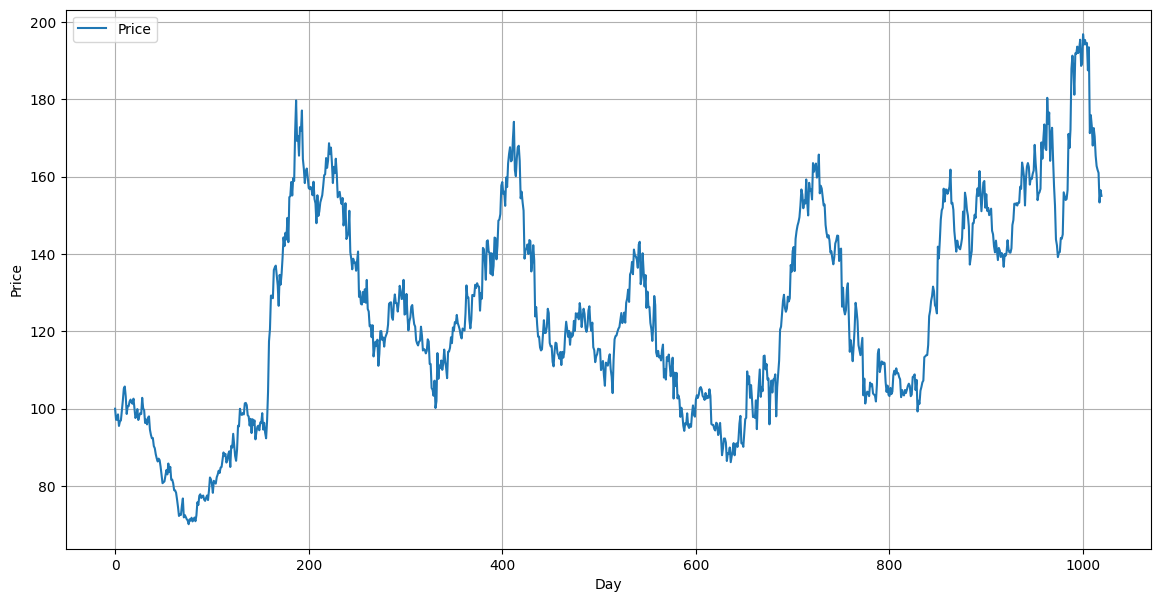

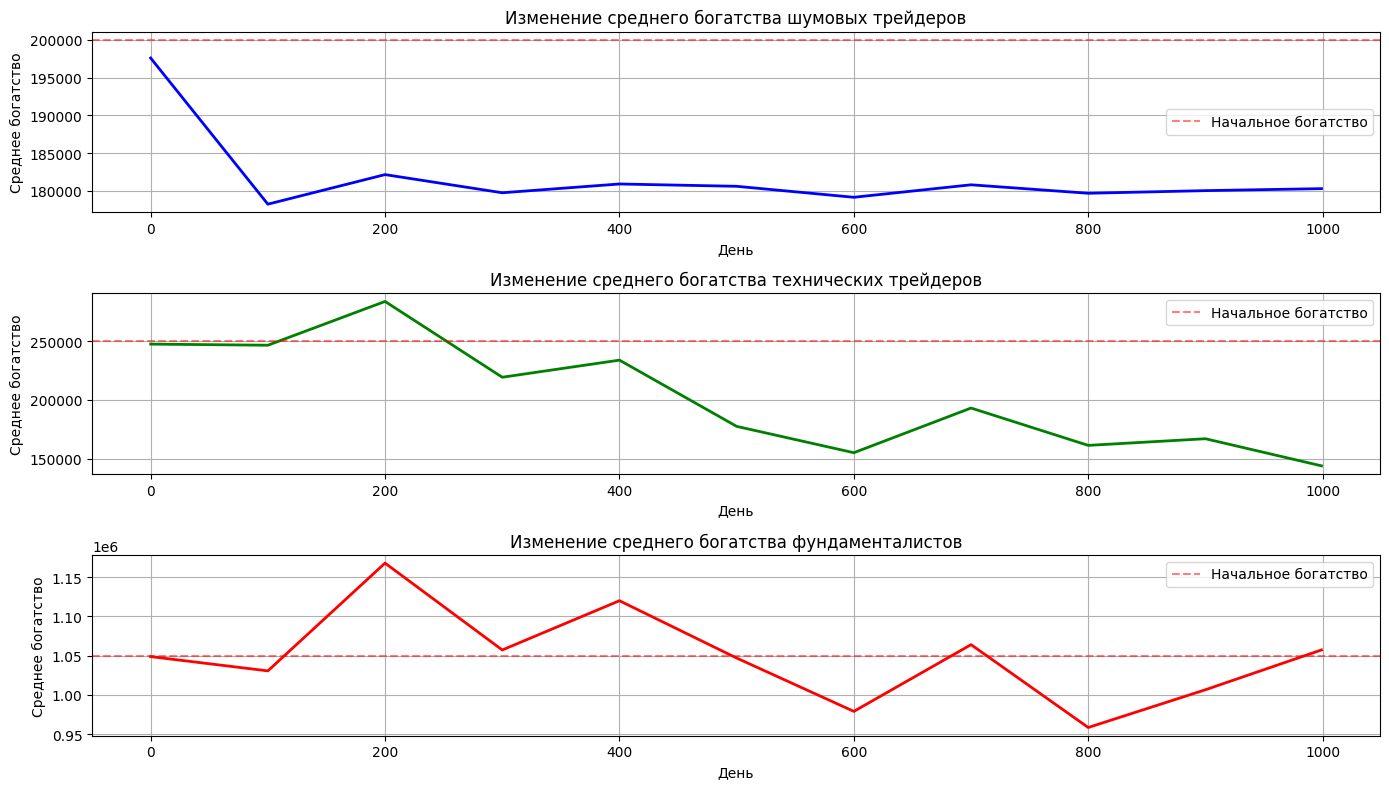

In [ ]:
asset, traders = run_simulation(days=1000)
plt.figure(figsize=(14, 7))
plt.plot(asset.price_history, label='Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(wealth_history['days'], wealth_history['noise_avg'], 'b-', linewidth=2)
plt.title('Изменение среднего богатства шумовых трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=200000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(wealth_history['days'], wealth_history['chartist_avg'], 'g-', linewidth=2)
plt.title('Изменение среднего богатства технических трейдеров')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=250000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(wealth_history['days'], wealth_history['fundamentalist_avg'], 'r-', linewidth=2)
plt.title('Изменение среднего богатства фундаменталистов')
plt.xlabel('День')
plt.ylabel('Среднее богатство')
plt.grid(True)
plt.axhline(y=1050000, color='r', linestyle='--', alpha=0.5, label='Начальное богатство')
plt.legend()
plt.tight_layout()
plt.show()

Также построим гистограммы распределений богатств, хотя в данном случае они не очень интересны:

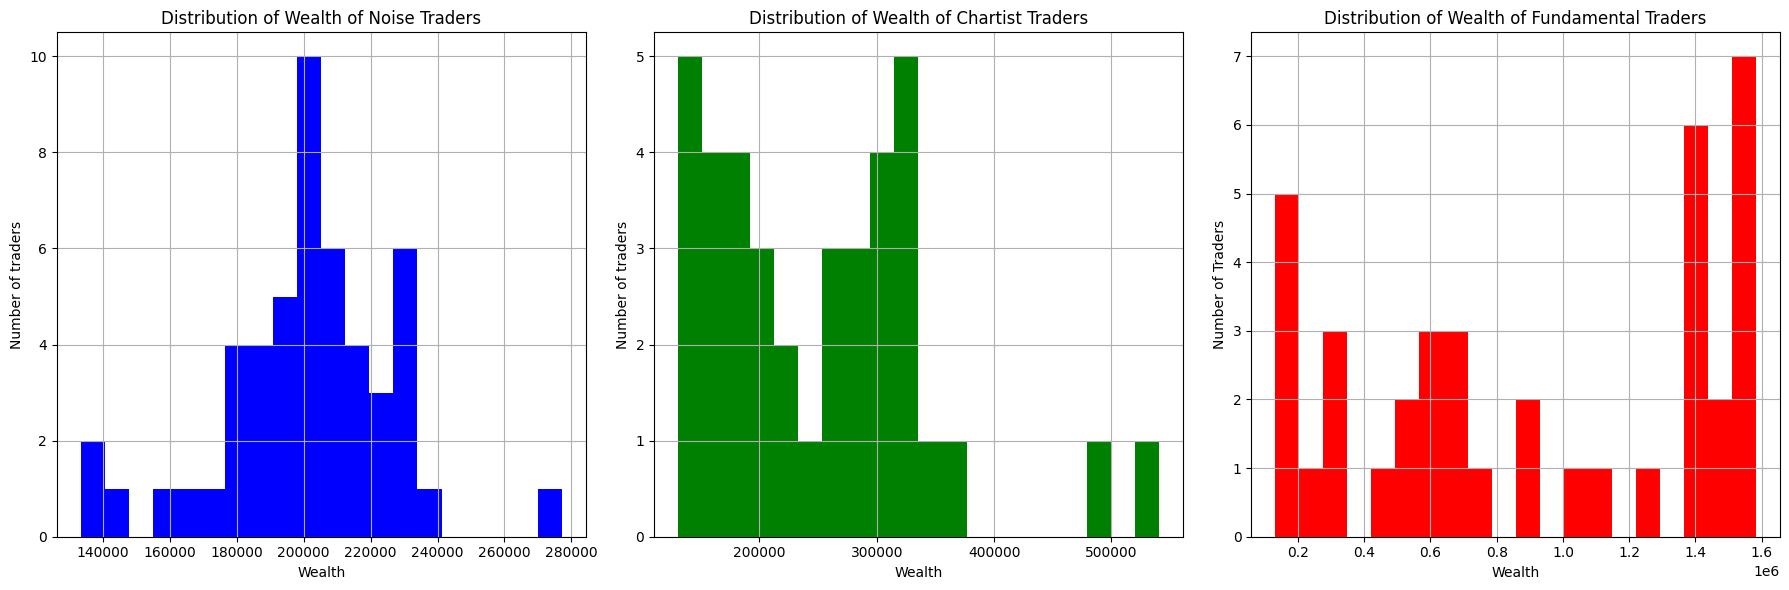

In [ ]:
noise_wealth = [t.wealth_history[-1] for t in traders if t.type == 'noise']
chartist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'chartist']
fundamentalist_wealth = [t.wealth_history[-1] for t in traders if t.type == 'fundamentalist']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(noise_wealth, bins=20, color='blue')
plt.title('Distribution of Wealth of Noise Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(chartist_wealth, bins=20, color='green')
plt.title('Distribution of Wealth of Chartist Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of traders')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(fundamentalist_wealth, bins=20, color='red')
plt.title('Distribution of Wealth of Fundamental Traders')
plt.xlabel('Wealth')
plt.ylabel('Number of Traders')
plt.grid(True)

plt.tight_layout()
plt.show()

Теперь посчитаем значения показателя Херста, Ляпунова и Энтропию Колмогорова-Синую на примере индекса РТС, ММВБ, S&P 500, DJIA, NASDAQ за период 09.05.2016 - 09.05.2026.

Для начала подгрузим данные:

In [19]:
rts = pd.read_csv('ртс.csv')
mmvb = pd.read_csv('ммвб.csv')
sp500 = pd.read_csv('s&p500.csv')
djia = pd.read_csv('djia.csv')
nasdaq = pd.read_csv('nasdaq.csv')
rts = rts[['Дата', 'Цена']]
mmvb = mmvb[['Дата', 'Цена']]
sp500 = sp500[['Дата', 'Цена']]
djia = djia[['Дата', 'Цена']]
nasdaq = nasdaq[['Дата', 'Цена']]
rts


,Дата,Цена
0,08.05.2026,"1.101,49"
1,07.05.2026,"1.104,09"
2,06.05.2026,"1.102,42"
3,05.05.2026,"1.105,63"
4,04.05.2026,"1.094,42"
...,...,...
2504,16.05.2016,"929,12"
2505,13.05.2016,"921,88"
2506,12.05.2016,"915,95"
2507,11.05.2016,"927,00"


Посчитаем указанные метрики:

In [20]:
def calculate_metrics(data, name):
    data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y')
    data['Цена'] = data['Цена'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.').astype(float)
    price_series = data['Цена'].values
    log_returns = np.diff(np.log(price_series))
    hurst = hurst_rs(log_returns)
    lyap = lyap_r(log_returns, emb_dim=10, lag=1)
    tolerance = 0.2 * np.std(log_returns)
    if tolerance == 0:
        tolerance = 0.01
    kse = sampen(log_returns, emb_dim=3, tolerance=tolerance)
    print(f"\n{name}")
    print(f"Показатель Херста: {hurst:.4f}")
    print(f"Показатель Ляпунова: {lyap:.6f}")
    print(f"Энтропия Колмогорова-Синая: {kse:.6f} бит/шаг")

calculate_metrics(rts, "РТС")
calculate_metrics(mmvb, "ММВБ")
calculate_metrics(sp500, "S&P500")
calculate_metrics(djia, "DJIA")
calculate_metrics(nasdaq, "NASDAQ")


РТС
Показатель Херста: 0.5226
Показатель Ляпунова: 0.003440
Энтропия Колмогорова-Синая: 1.601361 бит/шаг

ММВБ
Показатель Херста: 0.5398
Показатель Ляпунова: 0.003281
Энтропия Колмогорова-Синая: 1.517753 бит/шаг

S&P500
Показатель Херста: 0.5168
Показатель Ляпунова: 0.013124
Энтропия Колмогорова-Синая: 1.410588 бит/шаг

DJIA
Показатель Херста: 0.5231
Показатель Ляпунова: 0.008281
Энтропия Колмогорова-Синая: 1.470639 бит/шаг

NASDAQ
Показатель Херста: 0.5077
Показатель Ляпунова: 0.003362
Энтропия Колмогорова-Синая: 1.503435 бит/шаг
